In [2]:
# Importing Data:
from google.colab import files
uploaded = files.upload()

Saving train_NYC_inspection.parquet to train_NYC_inspection.parquet


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# loading parquet training dataset
df = pd.read_parquet("train_NYC_inspection.parquet")

df.head()

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,None


In [4]:
np.random.seed(42)

In [5]:
# data cleaning

# drop rows with missing target values
df = df.dropna(subset=["GRADE"])

# define features and target
target_col = "GRADE"
y = df[target_col].astype(str)

# drop non-essential columns for feature engineering
X = df.drop(columns=[target_col, "INSPECTION DATE", "BUILDING", "STREET"])

# encode categorical features: CUISINE DESCRIPTION and BORO
from sklearn.preprocessing import LabelEncoder

# first keep all non-dropped columns
# (CUISINE DESCRIPTION and BORO are still present here)
print("Columns before encoding:", list(X.columns))

# encode categorical features
cuisine_encoder = LabelEncoder()
X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"].astype(str))
X = X.drop(columns=["CUISINE DESCRIPTION"])

boro_encoder = LabelEncoder()
X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"].astype(str))
X = X.drop(columns=["BORO"])

# keep only numeric features
X = X.select_dtypes(include=[np.number]).copy()

# replace missing values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# remove rows where target has missing values (already dropped above, but keep consistent)
valid_idx = y.notna()
X = X[valid_idx].values.astype(np.float64)
y = y[valid_idx].values.astype(str)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Columns before encoding: ['CUISINE DESCRIPTION', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude']
Feature matrix shape: (68423, 5)
Target shape: (68423,)


In [6]:
# hyperparameter tuning for random forest

# encode target labels once
grade_encoder = LabelEncoder()
y_encoded = grade_encoder.fit_transform(y)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"],
}

# setup cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# initialize random forest base model (classifier)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# perform GridSearchCV
print("\nPerforming GridSearchCV for Random Forest (GRADE classification)")
total_combos = (
    len(rf_param_grid["n_estimators"])
    * len(rf_param_grid["max_depth"])
    * len(rf_param_grid["min_samples_split"])
    * len(rf_param_grid["min_samples_leaf"])
    * len(rf_param_grid["max_features"])
)
print(f"Total parameter combinations: {total_combos}")
print("Cross-validation: 5-Fold KFold\n")

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=kfold,
    scoring="f1_macro",   # more appropriate for multi-class grade
    n_jobs=-1,
    verbose=1,
)

rf_grid_search.fit(X, y_encoded)

print("BEST RANDOM FOREST MODEL (GRADE):\n")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best CV Macro F1: {rf_grid_search.best_score_:.4f}")

# evaluate on training set
rf_train_pred = rf_grid_search.predict(X)
rf_train_acc = accuracy_score(y_encoded, rf_train_pred)
rf_train_f1 = f1_score(y_encoded, rf_train_pred, average="macro")

print("\nTraining Set Performance:")
print(f"  Accuracy: {rf_train_acc:.4f}")
print(f"  Macro F1: {rf_train_f1:.4f}")

# store best scores/params for later comparison
best_rf_f1 = rf_grid_search.best_score_
best_rf_params = rf_grid_search.best_params_


Performing GridSearchCV for Random Forest (GRADE classification)
Total parameter combinations: 32
Cross-validation: 5-Fold KFold

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


BEST RANDOM FOREST MODEL (GRADE):

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Macro F1: 0.5618

Training Set Performance:
  Accuracy: 0.8677
  Macro F1: 0.6841


In [7]:
# gradient boosting hyperparameter tuning

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "subsample": [0.8, 1.0],
}

# initialize gradient boosting base model (classifier)
gb_base = GradientBoostingClassifier(random_state=42)

# perform GridSearchCV
print("\nPerforming GridSearchCV for Gradient Boosting (GRADE classification)")
total_gb_combos = (
    len(gb_param_grid["n_estimators"])
    * len(gb_param_grid["learning_rate"])
    * len(gb_param_grid["max_depth"])
    * len(gb_param_grid["min_samples_split"])
    * len(gb_param_grid["min_samples_leaf"])
    * len(gb_param_grid["subsample"])
)
print(f"Total parameter combinations: {total_gb_combos}")
print("Cross-validation: 5-Fold KFold\n")

gb_grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=gb_param_grid,
    cv=kfold,
    scoring="f1_macro",   # same metric as Random Forest
    n_jobs=-1,
    verbose=1,
)

gb_grid_search.fit(X, y_encoded)

print("BEST GRADIENT BOOSTING MODEL (GRADE):\n")
print(f"Best Parameters: {gb_grid_search.best_params_}")
print(f"Best CV Macro F1: {gb_grid_search.best_score_:.4f}")

# evaluate on training set
gb_train_pred = gb_grid_search.predict(X)
gb_train_acc = accuracy_score(y_encoded, gb_train_pred)
gb_train_f1 = f1_score(y_encoded, gb_train_pred, average="macro")

print("\nTraining Set Performance:")
print(f"Accuracy: {gb_train_acc:.4f}")
print(f"Macro F1: {gb_train_f1:.4f}")

# store best scores
best_gb_f1 = gb_grid_search.best_score_
best_gb_params = gb_grid_search.best_params_


Performing GridSearchCV for Gradient Boosting (GRADE classification)
Total parameter combinations: 64
Cross-validation: 5-Fold KFold

Fitting 5 folds for each of 64 candidates, totalling 320 fits
BEST GRADIENT BOOSTING MODEL (GRADE):

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Best CV Macro F1: 0.3149

Training Set Performance:
Accuracy: 0.6932
Macro F1: 0.3946


In [11]:
# comparing models

comparison_data = {
    "Model": ["Random Forest", "Gradient Boosting"],
    "CV Macro F1": [best_rf_f1, best_gb_f1],
    "Train Accuracy": [rf_train_acc, gb_train_acc],
    "Train Macro F1": [rf_train_f1, gb_train_f1],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# determine best ensemble model (by CV Macro F1)
if best_rf_f1 >= best_gb_f1:
    best_ensemble_name = "Random Forest"
    best_ensemble_cv_f1 = best_rf_f1
    best_ensemble_train_acc = rf_train_acc
    best_ensemble_train_f1 = rf_train_f1
else:
    best_ensemble_name = "Gradient Boosting"
    best_ensemble_cv_f1 = best_gb_f1
    best_ensemble_train_acc = gb_train_acc
    best_ensemble_train_f1 = gb_train_f1

print(f"\nBEST ENSEMBLE MODEL: {best_ensemble_name}")
print(f"CV Macro F1: {best_ensemble_cv_f1:.4f}")
print(f"Training Accuracy: {best_ensemble_train_acc:.4f}")
print(f"Training Macro F1: {best_ensemble_train_f1:.4f}")


            Model  CV Macro F1  Train Accuracy  Train Macro F1
    Random Forest     0.561841        0.867661        0.684085
Gradient Boosting     0.314905        0.693232        0.394584

BEST ENSEMBLE MODEL: Random Forest
CV Macro F1: 0.5618
Training Accuracy: 0.8677
Training Macro F1: 0.6841


In [12]:
# random forest feature importance
rf_importances = rf_grid_search.best_estimator_.feature_importances_
feature_names = [f"Feature_{i}" for i in range(len(rf_importances))]

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances,
    "Model": "Random Forest",
}).sort_values("Importance", ascending=False)

# gradient boosting feature importance
gb_importances = gb_grid_search.best_estimator_.feature_importances_

gb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_importances,
    "Model": "Gradient Boosting",
}).sort_values("Importance", ascending=False)

print("\nTop 10 Features - Random Forest:")
print(rf_importance_df.head(10).to_string(index=False))

print("\n\nTop 10 Features - Gradient Boosting:")
print(gb_importance_df.head(10).to_string(index=False))


Top 10 Features - Random Forest:
  Feature  Importance         Model
Feature_1    0.364228 Random Forest
Feature_2    0.359867 Random Forest
Feature_3    0.173033 Random Forest
Feature_0    0.095879 Random Forest
Feature_4    0.006992 Random Forest


Top 10 Features - Gradient Boosting:
  Feature  Importance             Model
Feature_1    0.363680 Gradient Boosting
Feature_2    0.344702 Gradient Boosting
Feature_3    0.211425 Gradient Boosting
Feature_0    0.072911 Gradient Boosting
Feature_4    0.007282 Gradient Boosting


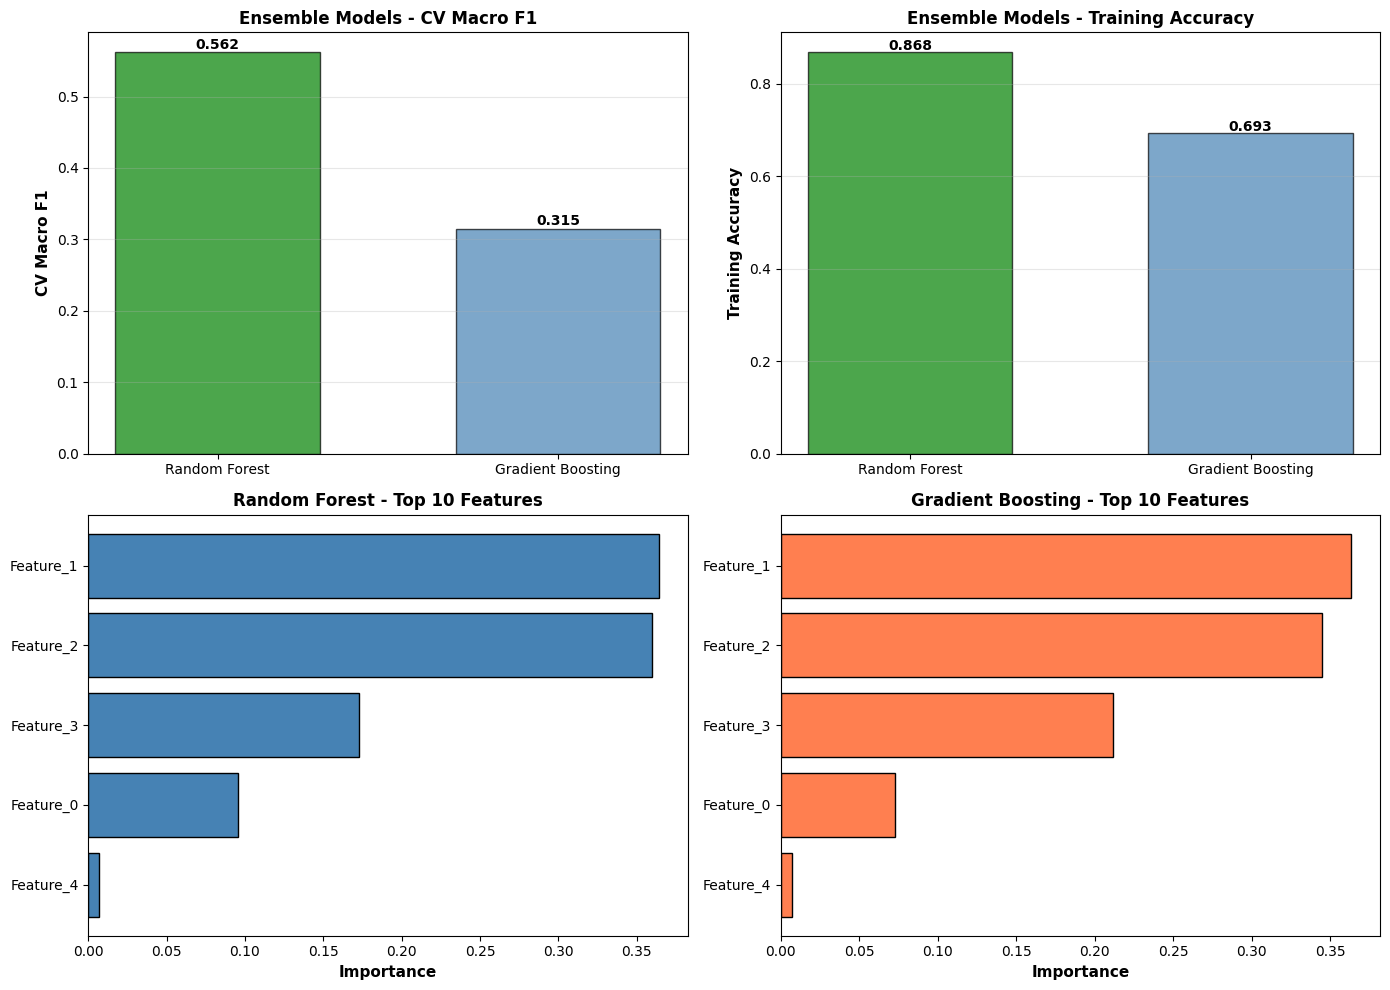

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ["Random Forest", "Gradient Boosting"]

# cv macro f1 comparison
ax1 = axes[0, 0]
cv_f1_scores = [best_rf_f1, best_gb_f1]
colors = ["green" if s == max(cv_f1_scores) else "steelblue" for s in cv_f1_scores]
ax1.bar(models, cv_f1_scores, color=colors, alpha=0.7, edgecolor="black", width=0.6)
ax1.set_ylabel("CV Macro F1", fontsize=11, fontweight="bold")
ax1.set_title("Ensemble Models - CV Macro F1", fontsize=12, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)
for i, (model, score) in enumerate(zip(models, cv_f1_scores)):
    ax1.text(i, score + 0.005, f"{score:.3f}", ha="center", fontweight="bold")

# training accuracy comparison
ax2 = axes[0, 1]
train_acc_scores = [rf_train_acc, gb_train_acc]
colors2 = ["green" if s == max(train_acc_scores) else "steelblue" for s in train_acc_scores]
ax2.bar(models, train_acc_scores, color=colors2, alpha=0.7, edgecolor="black", width=0.6)
ax2.set_ylabel("Training Accuracy", fontsize=11, fontweight="bold")
ax2.set_title("Ensemble Models - Training Accuracy", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
for i, (model, score) in enumerate(zip(models, train_acc_scores)):
    ax2.text(i, score + 0.005, f"{score:.3f}", ha="center", fontweight="bold")

# feature importance (random forest)
ax3 = axes[1, 0]
top_rf = rf_importance_df.head(10)
ax3.barh(range(len(top_rf)), top_rf["Importance"].values, color="steelblue", edgecolor="black")
ax3.set_yticks(range(len(top_rf)))
ax3.set_yticklabels(top_rf["Feature"].values)
ax3.set_xlabel("Importance", fontsize=11, fontweight="bold")
ax3.set_title("Random Forest - Top 10 Features", fontsize=12, fontweight="bold")
ax3.invert_yaxis()

# feature importance (gradient boosting)
ax4 = axes[1, 1]
top_gb = gb_importance_df.head(10)
ax4.barh(range(len(top_gb)), top_gb["Importance"].values, color="coral", edgecolor="black")
ax4.set_yticks(range(len(top_gb)))
ax4.set_yticklabels(top_gb["Feature"].values)
ax4.set_xlabel("Importance", fontsize=11, fontweight="bold")
ax4.set_title("Gradient Boosting - Top 10 Features", fontsize=12, fontweight="bold")
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
# train best Random Forest on full training set (GRADE classification)
print("\nTraining best Random Forest model on full training set:")
final_rf_model = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
final_rf_model.fit(X, y_encoded)
print("Random Forest training completed")

# train best Gradient Boosting on full training set (GRADE classification)
print("Training best Gradient Boosting model on full training set:")
final_gb_model = GradientBoostingClassifier(**best_gb_params, random_state=42)
final_gb_model.fit(X, y_encoded)
print("Gradient Boosting training completed")


Training best Random Forest model on full training set:
Random Forest training completed
Training best Gradient Boosting model on full training set:
Gradient Boosting training completed


In [15]:
print("RANDOM FOREST:\n")
print("Best Parameters:")
for param, value in best_rf_params.items():
    print(f"  {param}: {value}")
print("\nCross-Validated Performance:")
print(f"  CV Macro F1: {best_rf_f1:.4f}")
print("\nTraining Performance:")
print(f"  Accuracy:  {rf_train_acc:.4f}")
print(f"  Macro F1:  {rf_train_f1:.4f}")
print("\n")

print("GRADIENT BOOSTING:\n")
print("Best Parameters:")
for param, value in best_gb_params.items():
    print(f"  {param}: {value}")
print("\nCross-Validated Performance:")
print(f"  CV Macro F1: {best_gb_f1:.4f}")
print("\nTraining Performance:")
print(f"  Accuracy:  {gb_train_acc:.4f}")
print(f"  Macro F1:  {gb_train_f1:.4f}")

RANDOM FOREST:

Best Parameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 100

Cross-Validated Performance:
  CV Macro F1: 0.5618

Training Performance:
  Accuracy:  0.8677
  Macro F1:  0.6841


GRADIENT BOOSTING:

Best Parameters:
  learning_rate: 0.1
  max_depth: 5
  min_samples_leaf: 2
  min_samples_split: 10
  n_estimators: 200
  subsample: 0.8

Cross-Validated Performance:
  CV Macro F1: 0.3149

Training Performance:
  Accuracy:  0.6932
  Macro F1:  0.3946
